Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 195MB/s] 


Epoch 1 | AUC 0.8920 | ACC 0.7910 | Sens 0.727 | Spec 0.855
Epoch 2 | AUC 0.8924 | ACC 0.8113 | Sens 0.856 | Spec 0.767
Epoch 3 | AUC 0.8951 | ACC 0.8101 | Sens 0.825 | Spec 0.795
Epoch 4 | AUC 0.8952 | ACC 0.8133 | Sens 0.913 | Spec 0.714
Epoch 5 | AUC 0.8972 | ACC 0.8142 | Sens 0.916 | Spec 0.712
Epoch 6 | AUC 0.8971 | ACC 0.8186 | Sens 0.896 | Spec 0.742
Epoch 7 | AUC 0.8981 | ACC 0.8098 | Sens 0.930 | Spec 0.689
Epoch 8 | AUC 0.8989 | ACC 0.8130 | Sens 0.904 | Spec 0.722
Epoch 9 | AUC 0.8976 | ACC 0.8130 | Sens 0.941 | Spec 0.685
Epoch 10 | AUC 0.8978 | ACC 0.8121 | Sens 0.892 | Spec 0.733


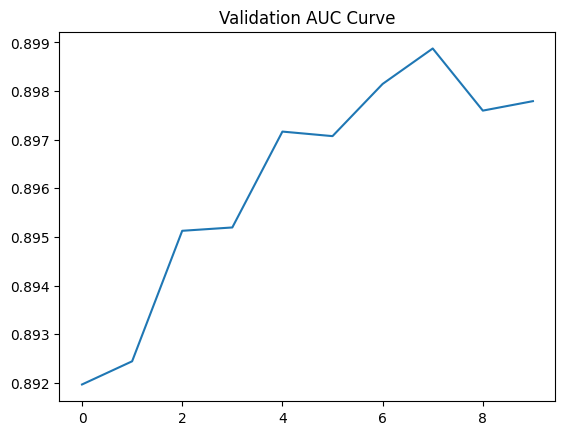

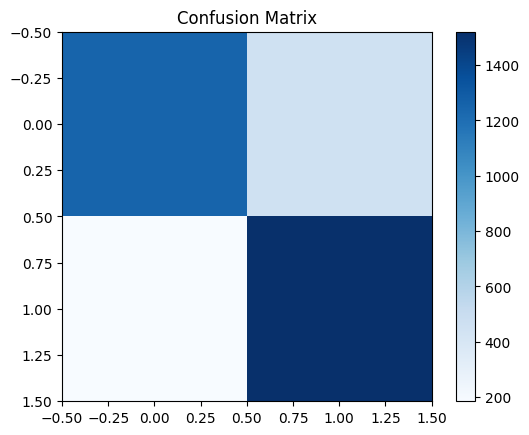

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

class CFG:
    CSV_PATH = "/kaggle/input/datasets/ahmedmohsen2005/final-processed-metadata/final_preprocessed_data.csv"
    IMG_ROOT = "/kaggle/input/notebooks/ahmedmohsen2005/xai-project"

    IMG_SIZE = 224
    BATCH = 32
    EPOCHS = 10
    LR = 3e-4

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class ISICDataset(Dataset):
    def __init__(self, df, file_map, tfm=None):
        self.df = df.reset_index(drop=True)
        self.file_map = file_map
        self.tfm = tfm

        self.meta_cols = [c for c in df.columns if c not in ["image","isic_id","patient_id","class"]]

        meta = df[self.meta_cols].values.astype(np.float32)
        self.meta_mean = meta.mean(0)
        self.meta_std = meta.std(0) + 1e-6

        meta = (meta - self.meta_mean) / self.meta_std

        self.meta = torch.tensor(meta, dtype=torch.float32)
        self.labels = torch.tensor(df["class"].values, dtype=torch.long)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img_id = str(r["isic_id"])
        path = self.file_map.get(img_id, None)

        if path and os.path.exists(path):
            img = Image.open(path).convert("RGB")
        else:
            img = Image.fromarray(np.zeros((224,224,3), dtype=np.uint8))

        if self.tfm:
            img = self.tfm(img)

        return img, self.meta[i], self.labels[i]

class ImageEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        self.backbone = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.proj = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        return self.proj(x)

class MetaEncoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 512)  # FIX: match image dim
        )

    def forward(self, x):
        return self.net(x)

class CrossAttention(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads=8, batch_first=True)
        self.norm = nn.LayerNorm(dim)

    def forward(self, img, meta):
        img = img.unsqueeze(1)
        meta = meta.unsqueeze(1)

        out1, _ = self.attn(img, meta, meta)
        out2, _ = self.attn(meta, img, img)

        out = self.norm(out1 + out2)
        return out.squeeze(1)

class ISICSOTA(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()
        self.img = ImageEncoder()
        self.meta = MetaEncoder(meta_dim)
        self.fusion = CrossAttention(dim=512)

        self.head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, img, meta):
        i = self.img(img)
        m = self.meta(meta)
        f = self.fusion(i, m)
        return self.head(f)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

def train():

    files = glob.glob(os.path.join(CFG.IMG_ROOT, "*.jpg"))
    file_map = {os.path.basename(f).split(".")[0]: f for f in files}

    df = pd.read_csv(CFG.CSV_PATH)
    tr, vl = train_test_split(df, test_size=0.2, stratify=df["class"], random_state=42)

    tfm = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(0.2,0.2,0.2,0.1),
        transforms.ToTensor()
    ])

    tr_ds = ISICDataset(tr, file_map, tfm)
    vl_ds = ISICDataset(vl, file_map, tfm)

    tr_dl = DataLoader(tr_ds, batch_size=CFG.BATCH, shuffle=True)
    vl_dl = DataLoader(vl_ds, batch_size=CFG.BATCH)

    model = ISICSOTA(len(tr_ds.meta_cols)).to(CFG.DEVICE)

    criterion = FocalLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=1e-2)

    train_auc = []

    for epoch in range(CFG.EPOCHS):

        model.train()
        for img, meta, y in tr_dl:
            img, meta, y = img.to(CFG.DEVICE), meta.to(CFG.DEVICE), y.to(CFG.DEVICE)

            opt.zero_grad()
            out = model(img, meta)
            loss = criterion(out, y)
            loss.backward()
            opt.step()

        model.eval()
        probs, preds, labels = [], [], []

        with torch.no_grad():
            for img, meta, y in vl_dl:
                img, meta = img.to(CFG.DEVICE), meta.to(CFG.DEVICE)

                out = model(img, meta)
                p = F.softmax(out,1)[:,1]
                pr = out.argmax(1)

                probs.extend(p.cpu().numpy())
                preds.extend(pr.cpu().numpy())
                labels.extend(y.numpy())

        auc = roc_auc_score(labels, probs)
        acc = accuracy_score(labels, preds)

        train_auc.append(auc)

        cm = confusion_matrix(labels, preds)
        tn, fp, fn, tp = cm.ravel()

        sens = tp/(tp+fn+1e-9)
        spec = tn/(tn+fp+1e-9)

        print(f"Epoch {epoch+1} | AUC {auc:.4f} | ACC {acc:.4f} | Sens {sens:.3f} | Spec {spec:.3f}")

    plt.figure()
    plt.plot(train_auc)
    plt.title("Validation AUC Curve")
    plt.show()

    plt.figure()
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.show()

if __name__ == "__main__":
    train()

In [12]:
import os, gc, warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

class CFG:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    IMG_SIZE = 224
    BATCH_SIZE = 16 
    EPOCHS = 10
    LR = 1e-4 
    TRAIN_CSV = "/kaggle/input/datasets/ahmedmohsen2005/final-processed-metadata/final_preprocessed_data.csv"
    IMG_DIR = "/kaggle/input/notebooks/ahmedmohsen2005/xai-project/final_processed_images"
    SEED = 42

class ISICDataset(Dataset):
    def __init__(self, df, img_dir, meta_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.meta_cols = meta_cols
        self.transform = transform
        
    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['isic_id']}.jpg")
        image = Image.open(img_path).convert("RGB")
        if self.transform: image = self.transform(image)
        meta = torch.tensor(row[self.meta_cols].values.astype(np.float32))
        label = torch.tensor(row['class'], dtype=torch.long)
        return image, meta, label

class GatedFusion(nn.Module):
    def __init__(self, img_dim, meta_dim, out_dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(img_dim + meta_dim, out_dim), nn.Sigmoid())
        self.img_proj = nn.Linear(img_dim, out_dim)
        self.meta_proj = nn.Linear(meta_dim, out_dim)

    def forward(self, img_feat, meta_feat):
        combined = torch.cat([img_feat, meta_feat], dim=1)
        g = self.gate(combined)
        return g * self.img_proj(img_feat) + (1 - g) * self.meta_proj(meta_feat)

class DaViTMultimodal(nn.Module):
    def __init__(self, num_meta):
        super().__init__()
        self.backbone = timm.create_model('davit_tiny', pretrained=True, num_classes=0)
        img_dim = self.backbone.num_features
        self.meta_branch = nn.Sequential(
            nn.Linear(num_meta, 128), nn.BatchNorm1d(128), nn.SiLU(),
            nn.Linear(128, 256), nn.SiLU()
        )
        self.fusion = GatedFusion(img_dim, 256, 512)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.SiLU(), nn.Dropout(0.5), nn.Linear(256, 2)
        )
        self.gradients = None
        self.last_layer = None

    def activations_hook(self, grad): self.gradients = grad

    def forward(self, img, meta):
        v_feat = self.backbone(img)
        # Hook for Grad-CAM
        if v_feat.requires_grad: v_feat.register_hook(self.activations_hook)
        self.last_layer = v_feat
        
        m_feat = self.meta_branch(meta)
        fused = self.fusion(v_feat, m_feat)
        return self.classifier(fused)

if __name__ == "__main__":
    df = pd.read_csv(CFG.TRAIN_CSV)
    meta_cols = [c for c in df.columns if c not in ['image', 'isic_id', 'patient_id', 'year', 'class']]
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['class'], random_state=CFG.SEED)

    # Strong Augmentation to fight memorization
    train_tfm = transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(0.1, 0.1, 0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    val_tfm = transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_loader = DataLoader(ISICDataset(train_df, CFG.IMG_DIR, meta_cols, train_tfm), batch_size=CFG.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(ISICDataset(val_df, CFG.IMG_DIR, meta_cols, val_tfm), batch_size=CFG.BATCH_SIZE)

    model = DaViTMultimodal(len(meta_cols)).to(CFG.DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Prevents hitting 1.000 AUC
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=CFG.LR, steps_per_epoch=len(train_loader), epochs=CFG.EPOCHS)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(1, CFG.EPOCHS + 1):
        model.train()
        t_t, t_p = [], []
        for imgs, metas, labels in train_loader:
            imgs, metas, labels = imgs.to(CFG.DEVICE), metas.to(CFG.DEVICE), labels.to(CFG.DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                logits = model(imgs, metas)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update(); scheduler.step()
            t_t.extend(labels.cpu().numpy()); t_p.extend(F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy())
        
        model.eval()
        v_t, v_p = [], []
        with torch.no_grad():
            for imgs, metas, labels in val_loader:
                imgs, metas, labels = imgs.to(CFG.DEVICE), metas.to(CFG.DEVICE), labels.to(CFG.DEVICE)
                logits = model(imgs, metas)
                v_t.extend(labels.cpu().numpy()); v_p.extend(F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy())
        
        print(f"Epoch {epoch} | Train AUC: {roc_auc_score(t_t, t_p):.4f} | Val AUC: {roc_auc_score(v_t, v_p):.4f}")
        gc.collect(); torch.cuda.empty_cache()

Epoch 1 | Train AUC: 0.7951 | Val AUC: 0.8914
Epoch 2 | Train AUC: 0.9164 | Val AUC: 0.9373
Epoch 3 | Train AUC: 0.9337 | Val AUC: 0.9458
Epoch 4 | Train AUC: 0.9486 | Val AUC: 0.9522
Epoch 5 | Train AUC: 0.9649 | Val AUC: 0.9528
Epoch 6 | Train AUC: 0.9794 | Val AUC: 0.9525
Epoch 7 | Train AUC: 0.9929 | Val AUC: 0.9508
Epoch 8 | Train AUC: 0.9982 | Val AUC: 0.9447
Epoch 9 | Train AUC: 0.9993 | Val AUC: 0.9456
Epoch 10 | Train AUC: 0.9998 | Val AUC: 0.9459


🚀 Environment Check: Device = cuda
✅ Metadata found at: /kaggle/input/datasets/ahmedmohsen2005/final-processed-metadata/final_preprocessed_data.csv
📊 Loading DataFrames...
🧠 Initializing DaViT Multimodal (Meta Dim: 29)...
⚡ Starting Training...

--- Epoch 1/5 ---
Batch 0/1706 | Loss: 0.6963
Batch 20/1706 | Loss: 0.6639
Batch 40/1706 | Loss: 0.6428
Batch 60/1706 | Loss: 0.6459
Batch 80/1706 | Loss: 0.6293
Batch 100/1706 | Loss: 0.6112
Batch 120/1706 | Loss: 0.6042
Batch 140/1706 | Loss: 0.5974
Batch 160/1706 | Loss: 0.5952
Batch 180/1706 | Loss: 0.5853
Batch 200/1706 | Loss: 0.5802
Batch 220/1706 | Loss: 0.5728
Batch 240/1706 | Loss: 0.5644
Batch 260/1706 | Loss: 0.5595
Batch 280/1706 | Loss: 0.5545
Batch 300/1706 | Loss: 0.5487
Batch 320/1706 | Loss: 0.5455
Batch 340/1706 | Loss: 0.5433
Batch 360/1706 | Loss: 0.5432
Batch 380/1706 | Loss: 0.5408
Batch 400/1706 | Loss: 0.5372
Batch 420/1706 | Loss: 0.5360
Batch 440/1706 | Loss: 0.5355
Batch 460/1706 | Loss: 0.5308
Batch 480/1706 | Loss:

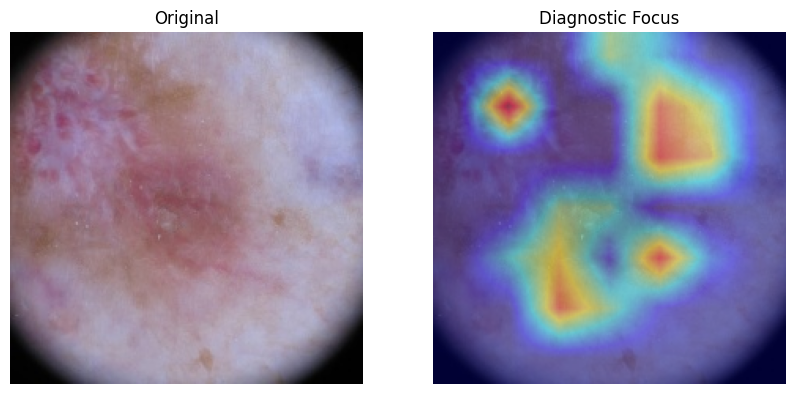

✅ Task Finished.


In [21]:
import os, gc, warnings, cv2, shap
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

class CFG:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    IMG_SIZE = 224
    BATCH_SIZE = 8  
    EPOCHS = 5      
    LR = 1e-4
    TRAIN_CSV = "/kaggle/input/datasets/ahmedmohsen2005/final-processed-metadata/final_preprocessed_data.csv"
    IMG_DIR = "/kaggle/input/notebooks/ahmedmohsen2005/xai-project/final_processed_images"
    SEED = 42

print(f"🚀 Environment Check: Device = {CFG.DEVICE}")
if os.path.exists(CFG.TRAIN_CSV):
    print(f"✅ Metadata found at: {CFG.TRAIN_CSV}")
else:
    print(f"❌ ERROR: CSV not found!")

class ISICDataset(Dataset):
    def __init__(self, df, img_dir, meta_cols, transform=None):
        self.df, self.img_dir, self.meta_cols, self.transform = df.reset_index(drop=True), img_dir, meta_cols, transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['isic_id']}.jpg")
        image = Image.open(img_path).convert("RGB")
        if self.transform: image = self.transform(image)
        meta = torch.tensor(row[self.meta_cols].values.astype(np.float32))
        label = torch.tensor(row['class'], dtype=torch.long)
        return image, meta, label

class GatedFusion(nn.Module):
    def __init__(self, img_dim, meta_dim, out_dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(img_dim + meta_dim, out_dim), nn.Sigmoid())
        self.img_proj = nn.Linear(img_dim, out_dim)
        self.meta_proj = nn.Linear(meta_dim, out_dim)
    def forward(self, img_f, meta_f):
        g = self.gate(torch.cat([img_f, meta_f], dim=1))
        return g * self.img_proj(img_f) + (1 - g) * self.meta_proj(meta_f)

class DaViTMultimodal(nn.Module):
    def __init__(self, num_meta):
        super().__init__()
        self.backbone = timm.create_model('davit_tiny', pretrained=True, num_classes=0)
        self.meta_branch = nn.Sequential(nn.Linear(num_meta, 128), nn.BatchNorm1d(128), nn.SiLU(), nn.Linear(128, 256), nn.SiLU())
        self.fusion = GatedFusion(self.backbone.num_features, 256, 512)
        self.classifier = nn.Sequential(nn.Linear(512, 256), nn.SiLU(), nn.Dropout(0.5), nn.Linear(256, 2))
        self.gradients, self.last_layer = None, None

    def activations_hook(self, grad): self.gradients = grad

    def forward(self, img, meta):
        v_feat = self.backbone.forward_features(img) 
        if v_feat.requires_grad: v_feat.register_hook(self.activations_hook)
        self.last_layer = v_feat
        
        v_feat_pooled = torch.mean(v_feat, dim=1) if len(v_feat.shape) == 3 else torch.mean(v_feat, dim=[2, 3])
        m_feat = self.meta_branch(meta)
        return self.classifier(self.fusion(v_feat_pooled, m_feat))

def run_isic_xai_study(model, df, meta_cols, img_dir):
    print("🎨 Initializing XAI Gallery...")
    model.eval()
    malignant = df[df['class'] == 1].sample(min(len(df[df['class']==1]), 1))
    if len(malignant) == 0: return
    
    row = malignant.iloc[0]
    orig_img = Image.open(os.path.join(img_dir, f"{row['isic_id']}.jpg")).convert("RGB").resize((224, 224))
    img_array = np.float32(orig_img) / 255
    input_t = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])(orig_img).unsqueeze(0).to(CFG.DEVICE)
    meta_t = torch.tensor(row[meta_cols].values.astype(np.float32)).unsqueeze(0).to(CFG.DEVICE)

    model.zero_grad(); output = model(input_t, meta_t); output[:, 1].backward()
    grads, acts = model.gradients.detach(), model.last_layer.detach()
    if len(grads.shape) == 3:
        b, n, c = grads.shape; h = int(np.sqrt(n))
        grads = grads.transpose(1, 2).view(b, c, h, h); acts = acts.transpose(1, 2).view(b, c, h, h)
    
    weights = torch.mean(grads, dim=[0, 2, 3])
    for i in range(acts.size(1)): acts[:, i, :, :] *= weights[i]
    heatmap = np.maximum(torch.mean(acts, dim=1).squeeze().cpu().numpy(), 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    
    cam = cv2.addWeighted(np.uint8(255 * img_array), 0.6, cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cv2.resize(heatmap, (224, 224))), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB), 0.4, 0)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(orig_img); plt.title("Original"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(cam); plt.title("Diagnostic Focus"); plt.axis('off')
    plt.show()

print("📊 Loading DataFrames...")
df = pd.read_csv(CFG.TRAIN_CSV)
meta_cols = [c for c in df.columns if c not in ['image', 'isic_id', 'patient_id', 'year', 'class']]
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['class'], random_state=CFG.SEED)

train_loader = DataLoader(ISICDataset(train_df, CFG.IMG_DIR, meta_cols, transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])), batch_size=CFG.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ISICDataset(val_df, CFG.IMG_DIR, meta_cols, transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])), batch_size=CFG.BATCH_SIZE)

print(f"🧠 Initializing DaViT Multimodal (Meta Dim: {len(meta_cols)})...")
model = DaViTMultimodal(len(meta_cols)).to(CFG.DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=0.05)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print("⚡ Starting Training...")
for epoch in range(1, CFG.EPOCHS + 1):
    print(f"\n--- Epoch {epoch}/{CFG.EPOCHS} ---")
    model.train(); t_l = []
    for i, (imgs, metas, labels) in enumerate(train_loader):
        imgs, metas, labels = imgs.to(CFG.DEVICE), metas.to(CFG.DEVICE), labels.to(CFG.DEVICE)
        optimizer.zero_grad(); logits = model(imgs, metas); loss = criterion(logits, labels)
        loss.backward(); optimizer.step()
        t_l.append(loss.item())
        if i % 20 == 0: print(f"Batch {i}/{len(train_loader)} | Loss: {np.mean(t_l):.4f}")

    model.eval(); v_p, v_t = [], []
    with torch.no_grad():
        for imgs, metas, labels in val_loader:
            logits = model(imgs.to(CFG.DEVICE), metas.to(CFG.DEVICE))
            v_p.extend(F.softmax(logits, dim=1)[:, 1].cpu().numpy())
            v_t.extend(labels.numpy())
    print(f"📊 Validation Complete | AUC: {roc_auc_score(v_t, v_p):.4f}")

print("\n🔍 Running Final Interpretability Study...")
run_isic_xai_study(model, val_df, meta_cols, CFG.IMG_DIR)
print("✅ Task Finished.")

In [1]:
!pip install lime captum -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.7 MB/s eta 0:00:00ta 0:00:01
